In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving diamonds.csv to diamonds.csv


In [3]:
df = pd.read_csv("diamonds.csv")

df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (53940, 11)

Columns:
Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (53940, 11)


In [8]:
print("========== MEAN ==========")
print(df.mean(numeric_only=True))

print("\n========== MEDIAN ==========")
print(df.median(numeric_only=True))

print("\n========== MODE ==========")
print(df.mode().iloc[0])

print("\n========== VARIANCE ==========")
print(df.var(numeric_only=True))

print("\n========== STANDARD DEVIATION ==========")
print(df.std(numeric_only=True))

========== MEAN ==========
Unnamed: 0    26970.500000
carat             0.797940
depth            61.749405
table            57.457184
price          3932.799722
x                 5.731157
y                 5.734526
z                 3.538734
dtype: float64

========== MEDIAN ==========
Unnamed: 0    26970.50
carat             0.70
depth            61.80
table            57.00
price          2401.00
x                 5.70
y                 5.71
z                 3.53
dtype: float64

========== MODE ==========
Unnamed: 0        1
carat           0.3
cut           Ideal
color             G
clarity         SI1
depth          62.0
table          56.0
price         605.0
x              4.37
y              4.34
z               2.7
Name: 0, dtype: object

========== VARIANCE ==========
Unnamed: 0    2.424648e+08
carat         2.246867e-01
depth         2.052404e+00
table         4.992948e+00
price         1.591563e+07
x             1.258347e+00
y             1.304472e+00
z             4.98010

In [9]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 3540


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
23820,23821,1.17,Ideal,F,VVS1,62.1,57.0,11886,6.82,6.73,4.21
23821,23822,2.08,Ideal,I,SI2,62.0,56.0,11886,8.21,8.10,5.06
23822,23823,1.70,Premium,I,VS2,62.2,58.0,11888,7.65,7.60,4.74
23823,23824,1.09,Ideal,F,IF,61.6,55.0,11888,6.59,6.65,4.08
23824,23825,1.68,Ideal,E,SI2,60.4,55.0,11888,7.79,7.70,4.68


In [10]:
df["price"] = np.where(df["price"] > upper, upper, df["price"])
df["price"] = np.where(df["price"] < lower, lower, df["price"])

print("Outliers treated successfully!")

Outliers treated successfully!


In [11]:
correlation = df.corr(numeric_only=True)

correlation

,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.377983,-0.034800,-0.100830,-0.354470,-0.405440,-0.395843,-0.399208
carat,-0.377983,1.000000,0.028224,0.181618,0.929103,0.975094,0.951722,0.953387
depth,-0.034800,0.028224,1.000000,-0.295779,-0.007205,-0.025289,-0.029341,0.094924
table,-0.100830,0.181618,-0.295779,1.000000,0.133574,0.195344,0.183760,0.150929
price,-0.354470,0.929103,-0.007205,0.133574,1.000000,0.910590,0.891128,0.887767
x,-0.405440,0.975094,-0.025289,0.195344,0.910590,1.000000,0.974701,0.970772
y,-0.395843,0.951722,-0.029341,0.183760,0.891128,0.974701,1.000000,0.952006
z,-0.399208,0.953387,0.094924,0.150929,0.887767,0.970772,0.952006,1.000000


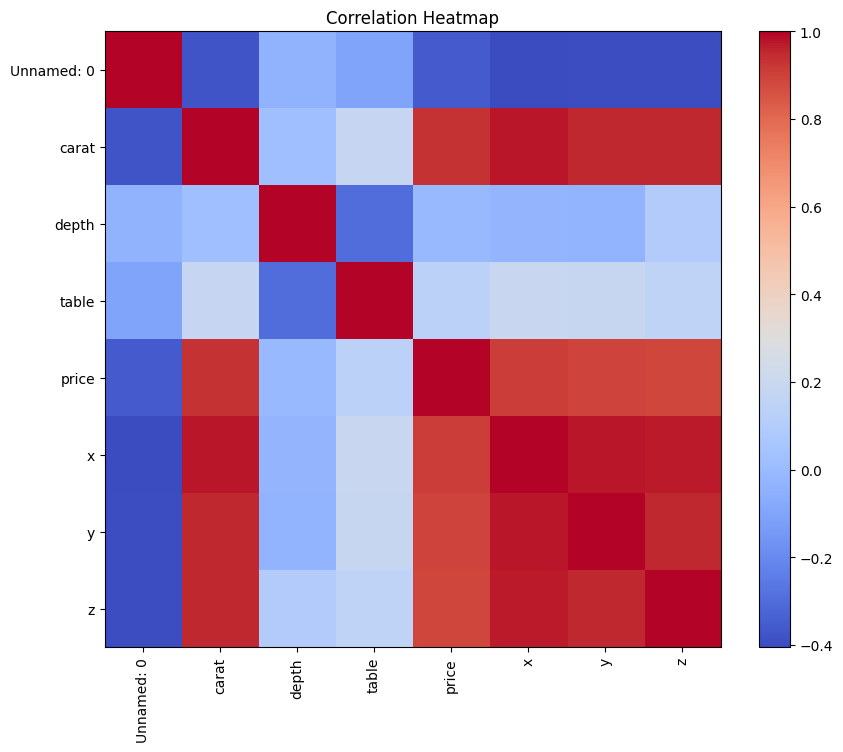

In [12]:
plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Heatmap")

plt.show()

In [14]:
expensive = df[df["price"] > 10000]

expensive.head()

excellent = df[df["cut"] == "Ideal"]

excellent.head()



,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
11,12,0.23,Ideal,J,VS1,62.8,56.0,340.0,3.93,3.90,2.46
13,14,0.31,Ideal,J,SI2,62.2,54.0,344.0,4.35,4.37,2.71
16,17,0.30,Ideal,I,SI2,62.0,54.0,348.0,4.31,4.34,2.68
39,40,0.33,Ideal,I,SI2,61.8,55.0,403.0,4.49,4.51,2.78


In [15]:
df.sort_values(by="price", ascending=False).head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
23820,23821,1.17,Ideal,F,VVS1,62.1,57.0,11885.625,6.82,6.73,4.21
23821,23822,2.08,Ideal,I,SI2,62.0,56.0,11885.625,8.21,8.10,5.06
23822,23823,1.70,Premium,I,VS2,62.2,58.0,11885.625,7.65,7.60,4.74
23823,23824,1.09,Ideal,F,IF,61.6,55.0,11885.625,6.59,6.65,4.08
27688,27689,1.51,Ideal,E,VS1,61.5,57.0,11885.625,7.34,7.40,4.53
27689,27690,1.72,Premium,G,VVS2,61.8,60.0,11885.625,7.65,7.68,4.74
27720,27721,2.02,Very Good,E,SI1,59.8,59.0,11885.625,8.11,8.20,4.88
27721,27722,1.94,Premium,F,SI1,62.6,58.0,11885.625,7.91,7.87,4.94
27722,27723,2.01,Ideal,G,SI1,62.1,57.0,11885.625,8.07,8.09,5.02
27723,27724,2.01,Ideal,G,SI1,62.2,56.0,11885.625,8.02,7.97,4.97


In [16]:
df.groupby("cut")["price"].mean()
df.groupby("color")["carat"].mean()

,carat
color,
D,0.657795
E,0.657867
F,0.736538
G,0.771190
H,0.911799
I,1.026927
J,1.162137


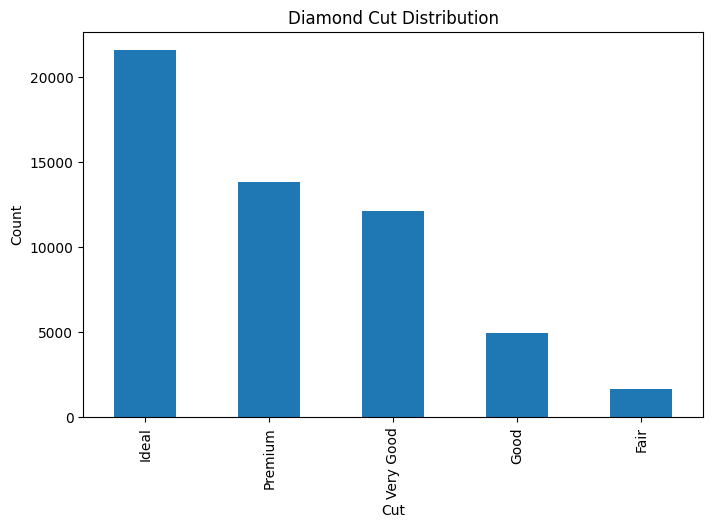

In [17]:
plt.figure(figsize=(8,5))

df["cut"].value_counts().plot(kind="bar")

plt.title("Diamond Cut Distribution")

plt.xlabel("Cut")

plt.ylabel("Count")

plt.show()

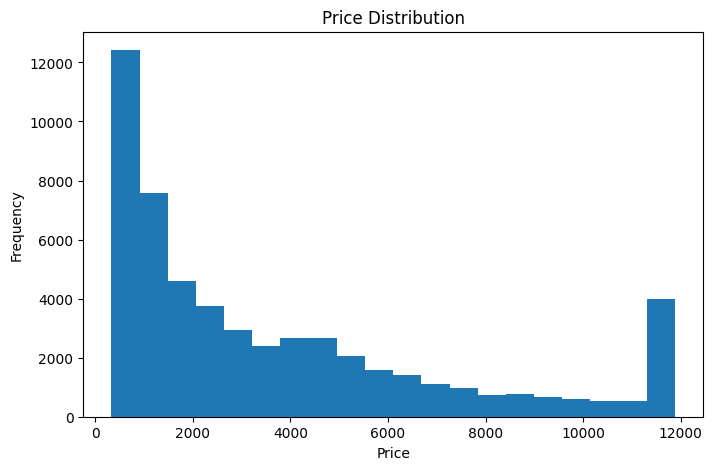

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=20)

plt.title("Price Distribution")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

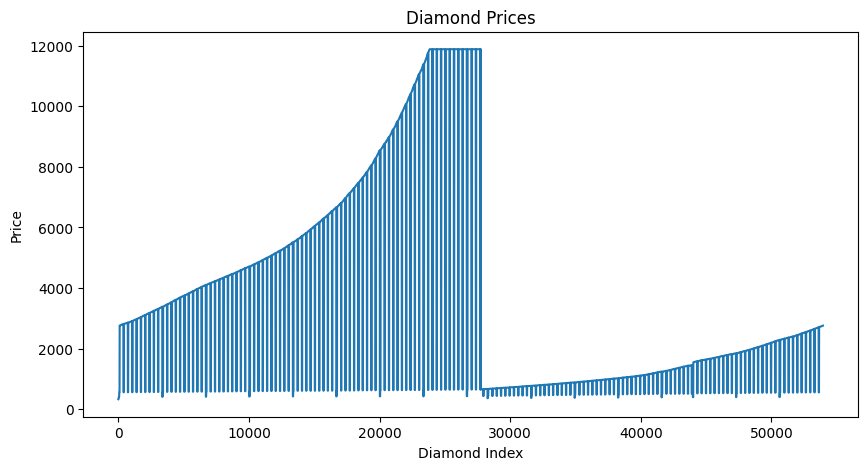

In [19]:
plt.figure(figsize=(10,5))

plt.plot(df["price"])

plt.title("Diamond Prices")

plt.xlabel("Diamond Index")

plt.ylabel("Price")

plt.show()

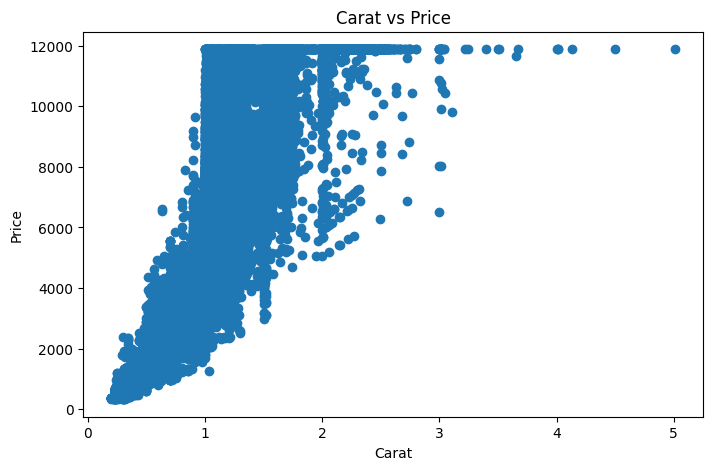

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df["carat"], df["price"])

plt.title("Carat vs Price")

plt.xlabel("Carat")

plt.ylabel("Price")

plt.show()

# Business Insights

- Diamonds with larger carat values generally have higher prices.
- Ideal cut diamonds are the most common in the dataset.
- Price varies significantly across different clarity grades.
- Higher-quality diamonds command premium prices.
- Outliers in price were identified and treated using the IQR method.
- Correlation analysis shows that carat has a strong positive relationship with price.